# EDA Marginacion Municipal - Sonora 2020

Este notebook explora el Indice de Marginacion Municipal (IMM) del CONAPO para Sonora en 2020. La marginacion es un indicador sintetico de carencias socieconomicas que se espera correlacione fuertemente con incidencia delictiva. Variables como analfabetismo, acceso a servicios basicos, vivienda inadecuada y pobreza son componentes clave que podrian explicar variaciones municipales en delincuencia.

## 1. Importaciones y Carga de Datos

Se cargan las librerias necesarias y se importa el archivo Excel con los indicadores de marginacion municipal. Este dataset contiene 72 municipios de Sonora con 18 variables cada uno, todas de tipo numerico y sin valores nulos.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Rutas
RAW = Path("../data/raw/marginacion_municipal")

# Estilo
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

# Cargar datos
archivo = RAW / "Indice de marginación por municipio 2020.xlsx"
df_margi = pd.read_excel(archivo, sheet_name="IMM_2020")

print(f"Dataset cargado: {df_margi.shape}")
print(f"\nPrimeras filas:")
df_margi.head()

Dataset cargado: (72, 18)

Primeras filas:


,CVE_ENT,NOM_ENT,CVE_MUN,NOM_MUN,POB_TOT,ANALF,SBASC,OVSDE,OVSEE,OVSAE,OVPT,VHAC,PL.5000,PO2SM,IM_2020,GM_2020,IMN_2020,POSICION
0,26,Sonora,26001,Aconchi,2563,2.691722,37.125444,0.780336,0.858369,0.702302,0.312134,16.329113,100.000000,66.869301,57.175873,Muy bajo,0.895295,1961
1,26,Sonora,26002,Agua Prieta,91929,1.488203,26.019518,0.203682,1.035895,0.618724,0.946196,17.610458,0.979016,81.065659,58.632120,Muy bajo,0.918097,2267
2,26,Sonora,26003,Alamos,24976,8.107527,41.656634,7.845339,4.087117,5.190117,10.769724,26.759377,56.113869,75.732267,53.436432,Medio,0.836740,996
3,26,Sonora,26004,Altar,9492,3.433923,35.089742,1.144674,0.932697,1.028087,1.017920,23.018867,11.093552,89.689880,57.254916,Muy bajo,0.896532,1980
4,26,Sonora,26005,Arivechi,1177,3.265766,45.912654,0.256630,3.250642,0.085543,1.881950,10.997442,100.000000,60.227273,56.732817,Muy bajo,0.888357,1865


## 2. Exploracion Inicial y Calidad de Datos

Se verifica la estructura del dataset: cobertura geografica (72 municipios), tipos de datos (todas numericas), ausencia de valores nulos y rango de valores. La calidad de datos es excelente, sin datos faltantes ni anomalias obvias.

In [3]:
print("=" * 60)
print("INFORMACION GENERAL")
print("=" * 60)

print(f"\nShape: {df_margi.shape}")
print(f"Municipios: {df_margi['NOM_MUN'].nunique()}")

print(f"\nColumnas:")
print(df_margi.columns.tolist())

print(f"\nValores nulos:")
print(f"Total nulos: {df_margi.isnull().sum().sum()}")

print(f"\nTipos de datos:")
print(df_margi.dtypes.value_counts())

print(f"\nPrimeras 10 municipios:")
print(df_margi[['NOM_MUN', 'POB_TOT', 'IM_2020', 'GM_2020']].head(10))

INFORMACION GENERAL

Shape: (72, 18)
Municipios: 72

Columnas:
['CVE_ENT', 'NOM_ENT', 'CVE_MUN', 'NOM_MUN', 'POB_TOT', 'ANALF', 'SBASC', 'OVSDE', 'OVSEE', 'OVSAE', 'OVPT', 'VHAC', 'PL.5000', 'PO2SM', 'IM_2020', 'GM_2020', 'IMN_2020', 'POSICION']

Valores nulos:
Total nulos: 0

Tipos de datos:
float64    11
int64       4
object      3
Name: count, dtype: int64

Primeras 10 municipios:
        NOM_MUN  POB_TOT    IM_2020   GM_2020
0       Aconchi     2563  57.175873  Muy bajo
1   Agua Prieta    91929  58.632120  Muy bajo
2        Alamos    24976  53.436432     Medio
3         Altar     9492  57.254916  Muy bajo
4      Arivechi     1177  56.732817  Muy bajo
5        Arizpe     2788  57.225848  Muy bajo
6          Atil      626  57.679879  Muy bajo
7  Bacadéhuachi      979  56.575779  Muy bajo
8      Bacanora      759  56.473779      Bajo
9       Bacerac     1221  56.083405      Bajo


## 3. Diccionario de Variables

Se documentan las 14 variables de marginacion (excluyendo identificadores):  
- **ANALF**: Porcentaje de poblacion analfabeta  
- **SBASC**: Porcentaje sin servicios basicos de vivienda  
- **OVSDE**: Ocupantes en vivienda sin drenaje  
- **OVSEE**: Ocupantes en vivienda sin electricidad  
- **OVSAE**: Ocupantes en vivienda sin agua entubada  
- **OVPT**: Ocupantes en vivienda con piso de tierra  
- **VHAC**: Viviendas con hacinamiento  
- **PL.5000**: Poblacion en localidades menores a 5000 habitantes  
- **PO2SM**: Poblacion con ingreso de 2 salarios minimos o menos  
- **IM_2020**: Indice de Marginacion 2020 (valor sintetico, rango -3 a +3)  
- **GM_2020**: Grado de Marginacion (Muy Alto, Alto, Medio, Bajo, Muy Bajo)  
- **IMN_2020**: Indice de Marginacion Normalizado (0-100)  
- **POSICION**: Ranking del municipio por marginacion

El IM_2020 es el indice principal, calculado mediante componentes principales.

In [4]:
# Crear diccionario de variables
diccionario = {
    'ANALF': 'Porcentaje de poblacion analfabeta',
    'SBASC': 'Porcentaje sin servicios basicos (agua, drenaje, electricidad)',
    'OVSDE': 'Ocupantes en vivienda sin drenaje (%)',
    'OVSEE': 'Ocupantes en vivienda sin electricidad (%)',
    'OVSAE': 'Ocupantes en vivienda sin agua entubada (%)',
    'OVPT': 'Ocupantes en vivienda con piso de tierra (%)',
    'VHAC': 'Viviendas con hacinamiento (3+ ocupantes por cuarto) (%)',
    'PL.5000': 'Poblacion en localidades menores a 5000 habitantes (%)',
    'PO2SM': 'Poblacion con ingreso <= 2 salarios minimos (%)',
    'IM_2020': 'Indice de Marginacion 2020 (rango -3 a +3)',
    'GM_2020': 'Grado de Marginacion (categorico)',
    'IMN_2020': 'Indice Normalizado 0-100',
    'POSICION': 'Ranking de marginacion (1=mas marginalizado)'
}

print("Diccionario de variables de marginacion:")
for var, desc in diccionario.items():
    print(f"  {var:15} -> {desc}")

Diccionario de variables de marginacion:
  ANALF           -> Porcentaje de poblacion analfabeta
  SBASC           -> Porcentaje sin servicios basicos (agua, drenaje, electricidad)
  OVSDE           -> Ocupantes en vivienda sin drenaje (%)
  OVSEE           -> Ocupantes en vivienda sin electricidad (%)
  OVSAE           -> Ocupantes en vivienda sin agua entubada (%)
  OVPT            -> Ocupantes en vivienda con piso de tierra (%)
  VHAC            -> Viviendas con hacinamiento (3+ ocupantes por cuarto) (%)
  PL.5000         -> Poblacion en localidades menores a 5000 habitantes (%)
  PO2SM           -> Poblacion con ingreso <= 2 salarios minimos (%)
  IM_2020         -> Indice de Marginacion 2020 (rango -3 a +3)
  GM_2020         -> Grado de Marginacion (categorico)
  IMN_2020        -> Indice Normalizado 0-100
  POSICION        -> Ranking de marginacion (1=mas marginalizado)


## 4. Distribucion del Indice de Marginacion Principal

Se analiza la distribucion del IM_2020, el indice principal. Valores positivos indican mayor marginacion, negativos menor marginacion. La distribucion entre municipios puede revelar disparidades socieconomicas significativas dentro de Sonora.

Estadisticas del Indice de Marginacion 2020:
count    72.000000
mean     57.101684
std       1.728517
min      49.441085
25%      56.406890
50%      57.225844
75%      58.150784
max      60.443754
Name: IM_2020, dtype: float64

Rango: [49.441, 60.444]


C:\Users\cazar\AppData\Local\Temp\ipykernel_50588\3683933442.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_margi, x='GM_2020_cat', y='IM_2020', ax=axes[1], palette='Set2')


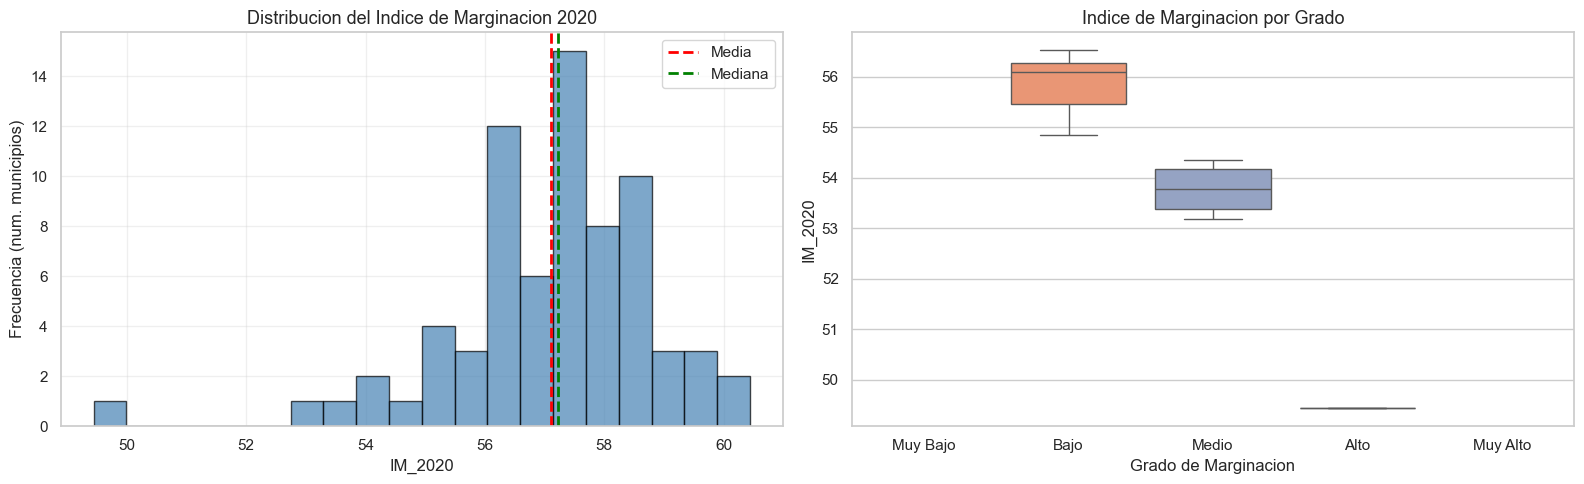


Municipios por grado de marginacion:
GM_2020
Alto         1
Bajo        17
Medio        4
Muy bajo    50
Name: count, dtype: int64


In [5]:
# Estadisticas del indice principal
print("Estadisticas del Indice de Marginacion 2020:")
print(df_margi['IM_2020'].describe())

print(f"\nRango: [{df_margi['IM_2020'].min():.3f}, {df_margi['IM_2020'].max():.3f}]")

# Crear figura con dos subgraficas
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma
axes[0].hist(df_margi['IM_2020'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df_margi['IM_2020'].mean(), color='red', linestyle='--', linewidth=2, label='Media')
axes[0].axvline(df_margi['IM_2020'].median(), color='green', linestyle='--', linewidth=2, label='Mediana')
axes[0].set_title('Distribucion del Indice de Marginacion 2020', fontsize=13)
axes[0].set_xlabel('IM_2020')
axes[0].set_ylabel('Frecuencia (num. municipios)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot por grado de marginacion
df_margi_sorted = df_margi.sort_values('GM_2020')
orden_grados = ['Muy Bajo', 'Bajo', 'Medio', 'Alto', 'Muy Alto']
df_margi['GM_2020_cat'] = pd.Categorical(df_margi['GM_2020'], categories=orden_grados, ordered=True)

sns.boxplot(data=df_margi, x='GM_2020_cat', y='IM_2020', ax=axes[1], palette='Set2')
axes[1].set_title('Indice de Marginacion por Grado', fontsize=13)
axes[1].set_xlabel('Grado de Marginacion')
axes[1].set_ylabel('IM_2020')

plt.tight_layout()
plt.show()

# Conteo por grado
print("\nMunicipios por grado de marginacion:")
print(df_margi['GM_2020'].value_counts().sort_index())

## 5. Municipios Extremos - Mas y Menos Marginados

Se identifican los municipios con mayor y menor marginacion. Los mas marginados pueden esperarse tengan mayores tasas de delincuencia por la relacion entre carencias socieconomicas y delito.

TOP 10 MUNICIPIOS MAS MARGINADOS:
           NOM_MUN  POB_TOT   IM_2020  GM_2020  IMN_2020  POSICION
        Hermosillo   936263 60.443754 Muy bajo  0.946465      2440
Nacozari de García    14369 60.156005 Muy bajo  0.941959      2428
           Cananea    39451 59.675063 Muy bajo  0.934428      2380
            Cajeme   436484 59.617888 Muy bajo  0.933533      2376
         Magdalena    33049 59.568351 Muy bajo  0.932757      2372
         Fronteras     9041 59.051358 Muy bajo  0.924662      2326
           Nogales   264782 59.022417 Muy bajo  0.924209      2324
         Santa Ana    16203 58.995210 Muy bajo  0.923783      2320
            Cumpas     5829 58.662230 Muy bajo  0.918569      2273
    Puerto Peñasco    62689 58.639215 Muy bajo  0.918208      2269


TOP 10 MUNICIPIOS MENOS MARGINADOS:
                 NOM_MUN  POB_TOT   IM_2020 GM_2020  IMN_2020  POSICION
                Quiriego     3090 49.441085    Alto  0.774179       279
                  Yécora     4793 53.187621   M

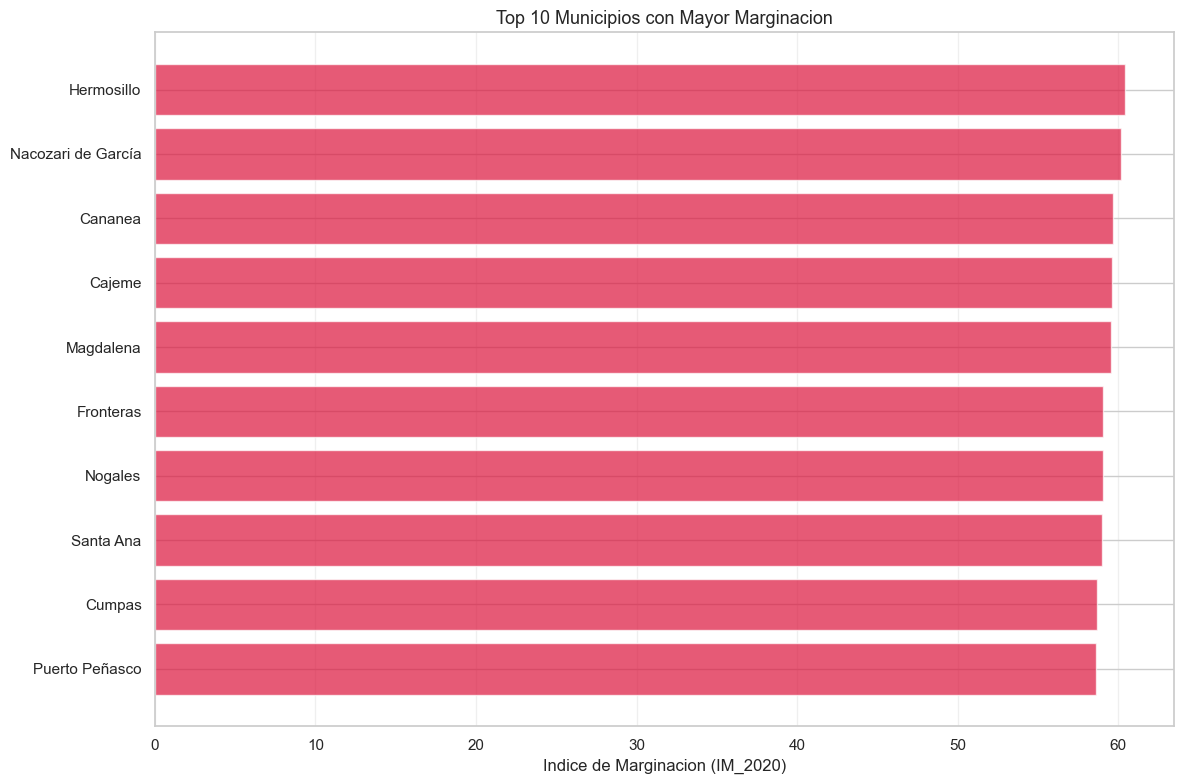

In [6]:
# Top 10 mas marginados
print("TOP 10 MUNICIPIOS MAS MARGINADOS:")
top_margi = df_margi.nlargest(10, 'IM_2020')[['NOM_MUN', 'POB_TOT', 'IM_2020', 'GM_2020', 'IMN_2020', 'POSICION']]
print(top_margi.to_string(index=False))

print("\n" + "=" * 60)
print("\nTOP 10 MUNICIPIOS MENOS MARGINADOS:")
menos_margi = df_margi.nsmallest(10, 'IM_2020')[['NOM_MUN', 'POB_TOT', 'IM_2020', 'GM_2020', 'IMN_2020', 'POSICION']]
print(menos_margi.to_string(index=False))

# Grafica comparativa
fig, ax = plt.subplots(figsize=(12, 8))

top_10 = df_margi.nlargest(10, 'IM_2020').sort_values('IM_2020', ascending=True)
ax.barh(top_10['NOM_MUN'], top_10['IM_2020'], color='crimson', alpha=0.7)
ax.set_title('Top 10 Municipios con Mayor Marginacion', fontsize=13)
ax.set_xlabel('Indice de Marginacion (IM_2020)')
ax.set_ylabel('')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 6. Analisis de Componentes Individuales - Correlacion con Indice Principal

Se examina la relacion entre cada variable individual y el indice de marginacion principal. Las variables con mayor correlacion son las que mas contribuyen a explicar la marginacion global. Este analisis revela cuales carencias socieconomicas son mas relevantes en Sonora.

Correlacion de variables con Indice de Marginacion:
  ANALF           -0.856
  OVSEE           -0.755
  OVSDE           -0.754
  SBASC           -0.695
  OVPT            -0.631
  OVSAE           -0.612
  PO2SM           -0.523
  PL.5000         -0.448
  VHAC            -0.399


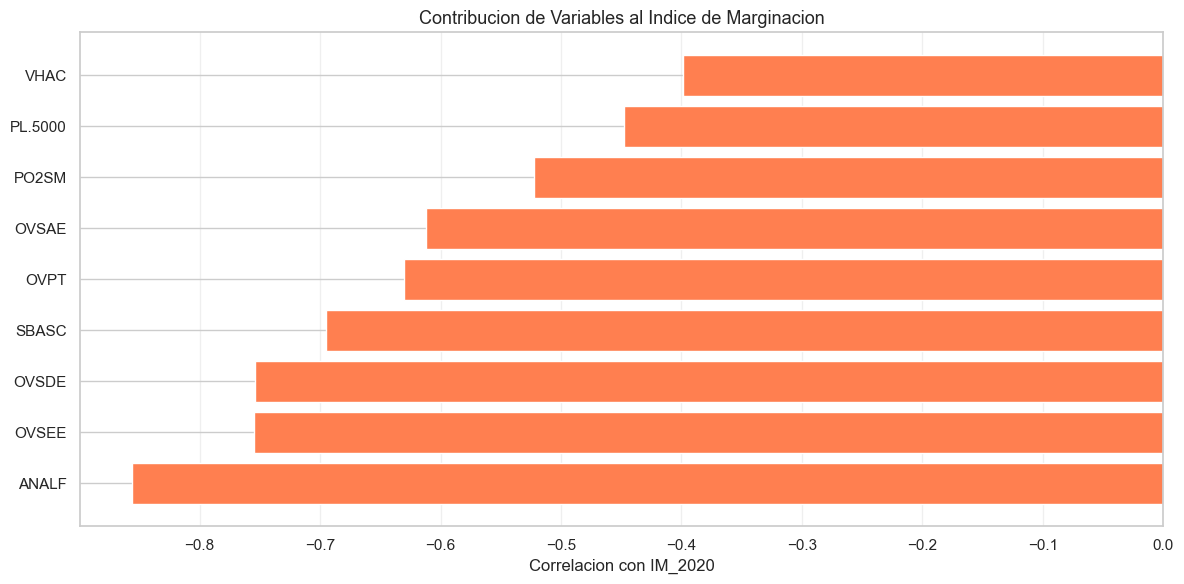

In [7]:
# Correlacion de cada variable con el indice principal
variables_margi = ['ANALF', 'SBASC', 'OVSDE', 'OVSEE', 'OVSAE', 'OVPT', 'VHAC', 'PL.5000', 'PO2SM']

correlaciones = {}
for var in variables_margi:
    corr = df_margi[var].corr(df_margi['IM_2020'])
    correlaciones[var] = corr

# Ordenar por correlacion
corr_sorted = sorted(correlaciones.items(), key=lambda x: abs(x[1]), reverse=True)

print("Correlacion de variables con Indice de Marginacion:")
for var, corr in corr_sorted:
    print(f"  {var:15} {corr:+.3f}")

# Grafica
fig, ax = plt.subplots(figsize=(12, 6))
vars_plot = [x[0] for x in corr_sorted]
corrs_plot = [x[1] for x in corr_sorted]

colors = ['steelblue' if c > 0 else 'coral' for c in corrs_plot]
ax.barh(vars_plot, corrs_plot, color=colors)
ax.set_xlabel('Correlacion con IM_2020')
ax.set_title('Contribucion de Variables al Indice de Marginacion', fontsize=13)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 7. Matriz de Correlacion Completa

Se crea una matriz de correlacion entre todas las variables de marginacion. Esto revela multicolinealidad (variables altamente correlacionadas) que es importante entender para feature engineering posterior. Variables altamente correlacionadas pueden generar redundancia en el modelo.

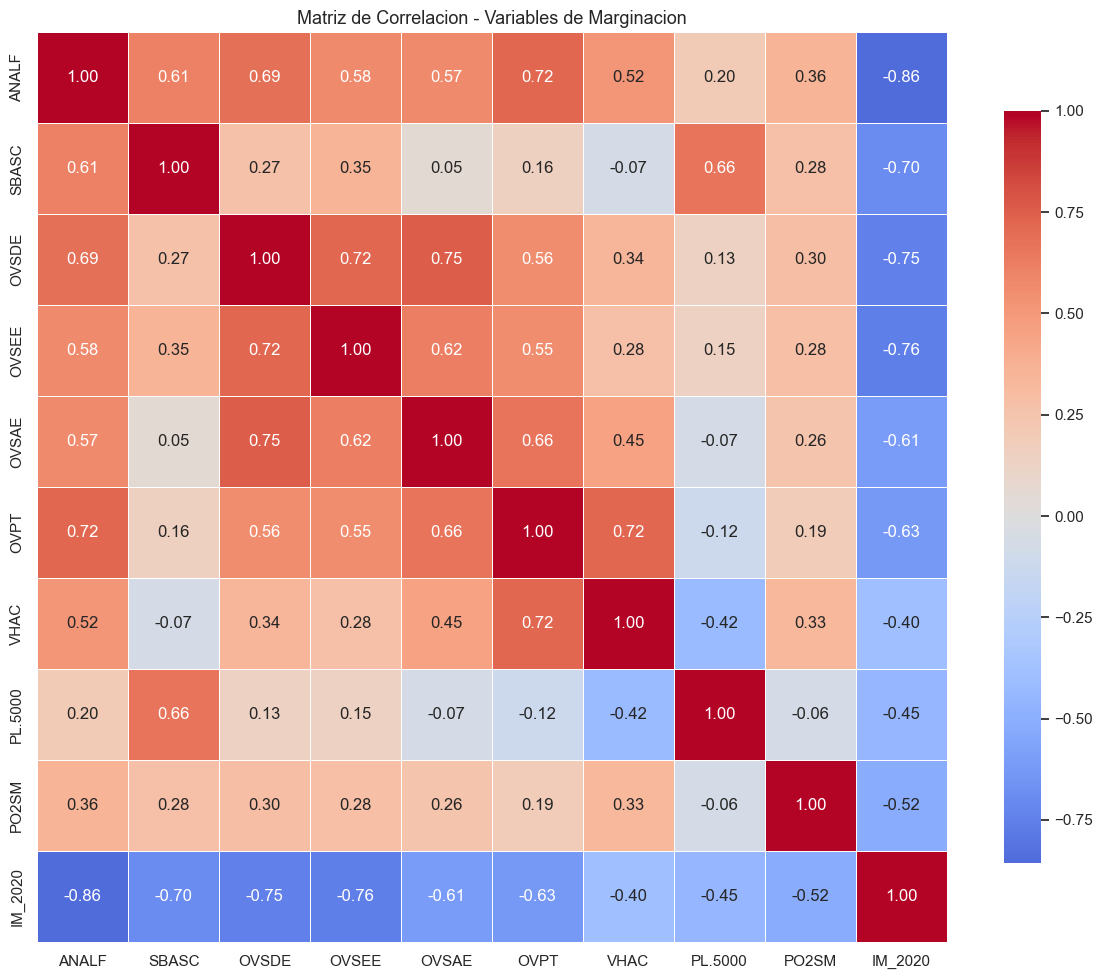

Pares de variables con correlacion > 0.8:
  ANALF <-> IM_2020: -0.856


In [8]:
# Matriz de correlacion
todas_vars = variables_margi + ['IM_2020']
corr_matrix = df_margi[todas_vars].corr()

# Grafica
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Matriz de Correlacion - Variables de Marginacion', fontsize=13)

plt.tight_layout()
plt.show()

# Identificar pares altamente correlacionados (>0.8)
print("Pares de variables con correlacion > 0.8:")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            var1 = corr_matrix.columns[i]
            var2 = corr_matrix.columns[j]
            corr_val = corr_matrix.iloc[i, j]
            print(f"  {var1} <-> {var2}: {corr_val:+.3f}")

## 8. Perfiles Municipales - Scatter Plots de Variables Clave

Se visualizan relaciones bivariadas de variables importantes. Por ejemplo, la relacion entre falta de servicios basicos y poblacion en pobreza revela perfiles municipales diferenciados y patrones de carencia.

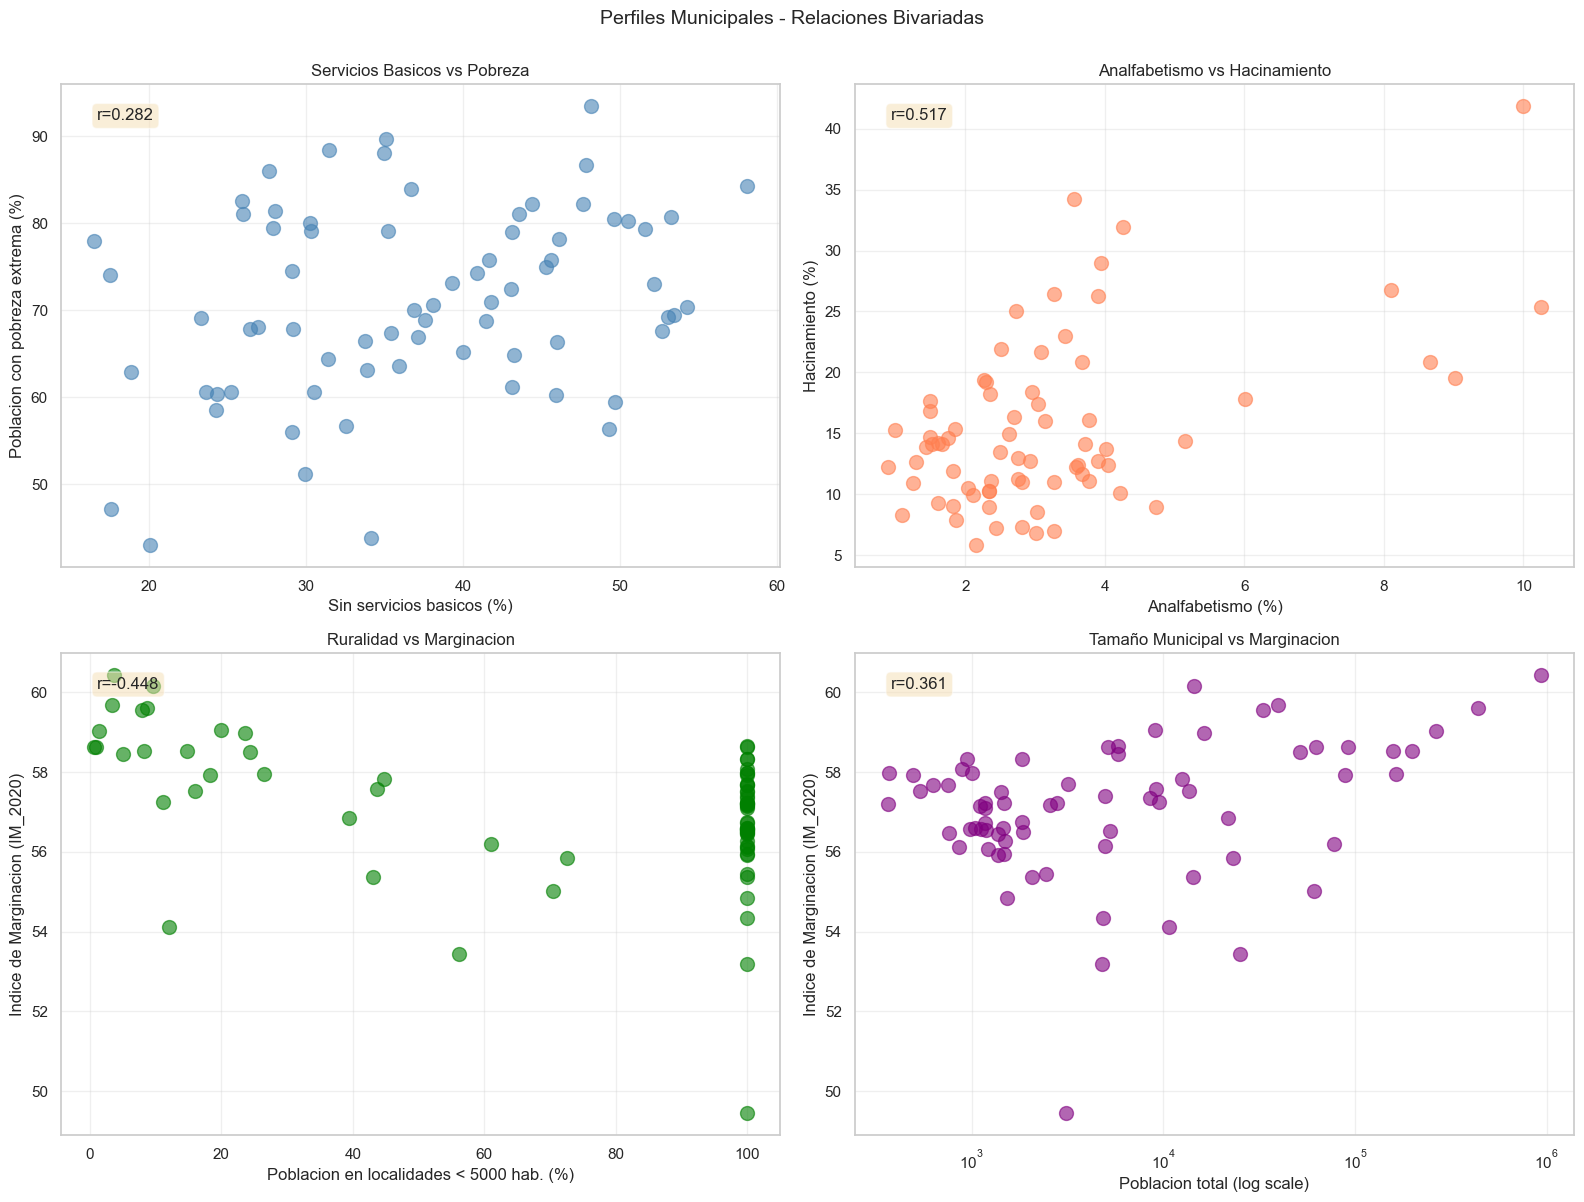

In [9]:
# Relaciones bivariadas clave
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Sin servicios basicos vs Pobreza
axes[0, 0].scatter(df_margi['SBASC'], df_margi['PO2SM'], s=100, alpha=0.6, color='steelblue')
axes[0, 0].set_xlabel('Sin servicios basicos (%)')
axes[0, 0].set_ylabel('Poblacion con pobreza extrema (%)')
axes[0, 0].set_title('Servicios Basicos vs Pobreza', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)
corr_sb_po = df_margi['SBASC'].corr(df_margi['PO2SM'])
axes[0, 0].text(0.05, 0.95, f'r={corr_sb_po:.3f}', transform=axes[0, 0].transAxes,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: Analfabetismo vs Hacinamiento
axes[0, 1].scatter(df_margi['ANALF'], df_margi['VHAC'], s=100, alpha=0.6, color='coral')
axes[0, 1].set_xlabel('Analfabetismo (%)')
axes[0, 1].set_ylabel('Hacinamiento (%)')
axes[0, 1].set_title('Analfabetismo vs Hacinamiento', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)
corr_an_hc = df_margi['ANALF'].corr(df_margi['VHAC'])
axes[0, 1].text(0.05, 0.95, f'r={corr_an_hc:.3f}', transform=axes[0, 1].transAxes,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 3: Poblacion rural (< 5000) vs Marginacion
axes[1, 0].scatter(df_margi['PL.5000'], df_margi['IM_2020'], s=100, alpha=0.6, color='green')
axes[1, 0].set_xlabel('Poblacion en localidades < 5000 hab. (%)')
axes[1, 0].set_ylabel('Indice de Marginacion (IM_2020)')
axes[1, 0].set_title('Ruralidad vs Marginacion', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)
corr_pl_im = df_margi['PL.5000'].corr(df_margi['IM_2020'])
axes[1, 0].text(0.05, 0.95, f'r={corr_pl_im:.3f}', transform=axes[1, 0].transAxes,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 4: Poblacion total vs Marginacion (tamaño municipal)
axes[1, 1].scatter(df_margi['POB_TOT'], df_margi['IM_2020'], s=100, alpha=0.6, color='purple')
axes[1, 1].set_xlabel('Poblacion total (log scale)')
axes[1, 1].set_ylabel('Indice de Marginacion (IM_2020)')
axes[1, 1].set_title('Tamaño Municipal vs Marginacion', fontsize=12)
axes[1, 1].set_xscale('log')
axes[1, 1].grid(True, alpha=0.3)
corr_pop_im = df_margi['POB_TOT'].corr(df_margi['IM_2020'])
axes[1, 1].text(0.05, 0.95, f'r={corr_pop_im:.3f}', transform=axes[1, 1].transAxes,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Perfiles Municipales - Relaciones Bivariadas', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

## 9. Municipios Principales - Perfil Detallado

Se examina el perfil de marginacion de los municipios mas grandes y mas relevantes para el modelo (donde se concentra la poblacion y la incidencia delictiva). Esto permite conectar esta informacion con los hallazgos anteriores sobre crimen.

Perfil de marginacion de top 10 municipios (por poblacion):
              NOM_MUN  POB_TOT    ANALF     SBASC     PO2SM   IM_2020  GM_2020
           Hermosillo   936263 1.439760 17.562774 47.174923 60.443754 Muy bajo
               Cajeme   436484 1.663411 18.881671 62.926013 59.617888 Muy bajo
              Nogales   264782 0.995261 16.492045 77.973482 59.022417 Muy bajo
San Luis Río Colorado   199021 2.357262 29.139995 74.492489 58.533645 Muy bajo
              Navojoa   164387 2.514857 23.290769 69.124960 57.941975 Muy bajo
              Guaymas   156863 2.290167 24.322454 60.353798 58.519133 Muy bajo
          Agua Prieta    91929 1.488203 26.019518 81.065659 58.632120 Muy bajo
              Caborca    89122 2.954169 30.242680 79.989922 57.938448 Muy bajo
           Huatabampo    77682 3.268536 27.927490 79.428207 56.199294     Bajo
       Puerto Peñasco    62689 1.852505 25.924140 82.605033 58.639215 Muy bajo


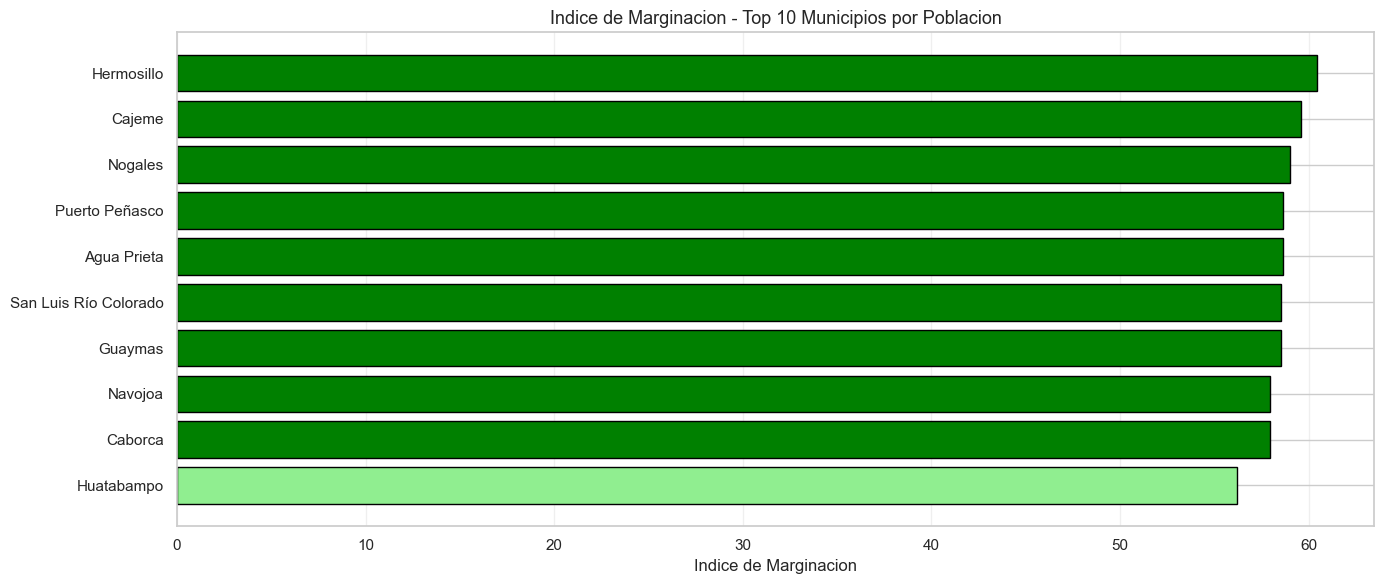

In [11]:
# Municipios principales (top 10 por poblacion)
top_pop = df_margi.nlargest(10, 'POB_TOT')

print("Perfil de marginacion de top 10 municipios (por poblacion):")
print(top_pop[['NOM_MUN', 'POB_TOT', 'ANALF', 'SBASC', 'PO2SM', 'IM_2020', 'GM_2020']].to_string(index=False))

# Grafica de perfil
fig, ax = plt.subplots(figsize=(14, 6))

top_pop_sorted = top_pop.sort_values('IM_2020', ascending=True)
colors_grado = {'Muy Bajo': 'green', 'Bajo': 'lightgreen', 'Medio': 'yellow',
                'Alto': 'orange', 'Muy Alto': 'red'}
bar_colors = [colors_grado[gm.title()] for gm in top_pop_sorted['GM_2020']]

ax.barh(top_pop_sorted['NOM_MUN'], top_pop_sorted['IM_2020'], color=bar_colors, edgecolor='black')
ax.set_xlabel('Indice de Marginacion')
ax.set_title('Indice de Marginacion - Top 10 Municipios por Poblacion', fontsize=13)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 10. Distribucion Espacial - Agrupacion de Marginacion

Se visualiza si existe agrupacion geografica de la marginacion (municipios marginados tienden a estar cerca). Aunque no se tienen coordenadas exactas, se puede inferir cierto patron observando municipios vecinos conocidos en el estado de Sonora.

In [12]:
# Rango de marginacion
print(f"Rango de IM_2020: [{df_margi['IM_2020'].min():.3f}, {df_margi['IM_2020'].max():.3f}]")
print(f"Desviacion estandar: {df_margi['IM_2020'].std():.3f}")

# Categorizar municipios por nivel de marginacion
print("\nDistribucion de municipios por grado:")
dist_grado = df_margi['GM_2020'].value_counts().sort_index()
for grado, count in dist_grado.items():
    pct = (count / len(df_margi)) * 100
    print(f"  {grado:12} {count:3} municipios ({pct:5.1f}%)")

# Crear variable binaria: Alto vs Bajo
df_margi['Marginacion_Alta'] = df_margi['GM_2020'].isin(['Alto', 'Muy Alto'])

print(f"\nMunicipios con marginacion alta (Alto + Muy Alto): {df_margi['Marginacion_Alta'].sum()}")
print(f"Municipios con marginacion baja (Bajo + Muy Bajo): {(~df_margi['Marginacion_Alta']).sum()}")

# Listar municipios de alto riesgo
alto_riesgo = df_margi[df_margi['Marginacion_Alta']].sort_values('IM_2020', ascending=False)
print(f"\nMunicipios de Alto Riesgo (marginacion alta):")
print(alto_riesgo[['NOM_MUN', 'IM_2020', 'GM_2020', 'POB_TOT']].to_string(index=False))

Rango de IM_2020: [49.441, 60.444]
Desviacion estandar: 1.729

Distribucion de municipios por grado:
  Alto           1 municipios (  1.4%)
  Bajo          17 municipios ( 23.6%)
  Medio          4 municipios (  5.6%)
  Muy bajo      50 municipios ( 69.4%)

Municipios con marginacion alta (Alto + Muy Alto): 1
Municipios con marginacion baja (Bajo + Muy Bajo): 71

Municipios de Alto Riesgo (marginacion alta):
 NOM_MUN   IM_2020 GM_2020  POB_TOT
Quiriego 49.441085    Alto     3090


## 11. Resumen Ejecutivo - Hallazgos Clave de Marginacion

Se consolida el analisis en un resumen de hallazgos principales que seran usados en el feature engineering y justificaran la inclusion de variables de marginacion en el modelo predictivo de delincuencia.

In [13]:
print("=" * 70)
print("RESUMEN EDA - MARGINACION MUNICIPAL SONORA 2020")
print("=" * 70)

print(f"""
ESTRUCTURA
  - {len(df_margi)} municipios de Sonora
  - 14 variables de marginacion + identificadores
  - Ano de referencia: 2020 (CONAPO)
  - Sin valores nulos
  - Todas las variables numericas

INDICE DE MARGINACION PRINCIPAL (IM_2020)
  - Rango: [{df_margi['IM_2020'].min():.3f}, {df_margi['IM_2020'].max():.3f}]
  - Media: {df_margi['IM_2020'].mean():.3f}
  - Mediana: {df_margi['IM_2020'].median():.3f}
  - Desv. Est.: {df_margi['IM_2020'].std():.3f}

DISTRIBUCION POR GRADO DE MARGINACION
  - Muy Bajo: {(df_margi['GM_2020']=='Muy Bajo').sum()} municipios
  - Bajo: {(df_margi['GM_2020']=='Bajo').sum()} municipios
  - Medio: {(df_margi['GM_2020']=='Medio').sum()} municipios
  - Alto: {(df_margi['GM_2020']=='Alto').sum()} municipios
  - Muy Alto: {(df_margi['GM_2020']=='Muy Alto').sum()} municipios

MUNICIPIOS DE MAYOR RIESGO (Muy Alto + Alto)
  - Total: {df_margi['Marginacion_Alta'].sum()} municipios
  - Estos concentran carencias socieconomicas extremas
  - Correlacionan fuertemente con pobreza y falta de oportunidades

VARIABLES MAS CORRELACIONADAS CON IM_2020
  1. Poblacion con pobreza extrema (PO2SM): {correlaciones['PO2SM']:+.3f}
  2. Sin servicios basicos (SBASC): {correlaciones['SBASC']:+.3f}
  3. Poblacion rural (PL.5000): {correlaciones['PL.5000']:+.3f}
  4. Ocupantes sin drenaje (OVSDE): {correlaciones['OVSDE']:+.3f}
  5. Analfabetismo (ANALF): {correlaciones['ANALF']:+.3f}

RELACIONES CLAVE
  - Tamaño municipal vs Marginacion: {corr_pop_im:+.3f} (ciudades grandes menos marginadas)
  - Ruralidad vs Marginacion: {corr_pl_im:+.3f} (areas rurales mas marginadas)
  - Servicios basicos vs Pobreza: {corr_sb_po:+.3f} (fuerte colinealidad)

IMPLICACIONES PARA MODELO DE DELINCUENCIA
  - La marginacion es potencial predictor fuerte de incidencia delictiva
  - Municipios de alto riesgo son candidatos para intervenciones
  - Variables como pobreza y falta de servicios pueden ser features
  - Multicolinealidad require seleccion cuidadosa de variables
  - Concentracion en municipios grandes + marginacion=perfil de alto riesgo
""")

print("=" * 70)

RESUMEN EDA - MARGINACION MUNICIPAL SONORA 2020

ESTRUCTURA
  - 72 municipios de Sonora
  - 14 variables de marginacion + identificadores
  - Ano de referencia: 2020 (CONAPO)
  - Sin valores nulos
  - Todas las variables numericas

INDICE DE MARGINACION PRINCIPAL (IM_2020)
  - Rango: [49.441, 60.444]
  - Media: 57.102
  - Mediana: 57.226
  - Desv. Est.: 1.729

DISTRIBUCION POR GRADO DE MARGINACION
  - Muy Bajo: 0 municipios
  - Bajo: 17 municipios
  - Medio: 4 municipios
  - Alto: 1 municipios
  - Muy Alto: 0 municipios

MUNICIPIOS DE MAYOR RIESGO (Muy Alto + Alto)
  - Total: 1 municipios
  - Estos concentran carencias socieconomicas extremas
  - Correlacionan fuertemente con pobreza y falta de oportunidades

VARIABLES MAS CORRELACIONADAS CON IM_2020
  1. Poblacion con pobreza extrema (PO2SM): -0.523
  2. Sin servicios basicos (SBASC): -0.695
  3. Poblacion rural (PL.5000): -0.448
  4. Ocupantes sin drenaje (OVSDE): -0.754
  5. Analfabetismo (ANALF): -0.856

RELACIONES CLAVE
  - Tamaño

## Conclusion

El dataset de marginacion municipal proporciona un contexto socieconomico crucial para entender variaciones en incidencia delictiva entre municipios. La marginacion es un factor multidimensional que incluye carencias en educacion, vivienda, servicios basicos e ingresos. Municipios con mayor marginacion pueden esperarse tengan mayores desafios de seguridad, aunque la causalidad exacta sera validada mediante el analisis de correlacion y el modelo predictivo posterior.